In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("clean_customer_data.csv")

In [4]:
import joblib

rf_model = joblib.load("rf_churn_model.pkl")

In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [16]:
df["Recommended_Action"] = df.apply(recommend_action, axis=1)

NameError: name 'recommend_action' is not defined

In [6]:
df_encoded = df_encoded.reindex(columns=rf_model.feature_names_in_, fill_value=0)

In [7]:
churn_prob = rf_model.predict_proba(df_encoded)[:,1]

df["Churn_Probability"] = churn_prob

In [8]:
def risk_category(prob):
    if prob > 0.6:
        return "High Risk"
    elif prob > 0.3:
        return "Medium Risk"
    else:
        return "Low Risk"

df["Risk_Level"] = df["Churn_Probability"].apply(risk_category)

In [15]:
seg_df = pd.read_csv("customer_segments.csv")

df = df.merge(seg_df[["Segment"]], left_index=True, right_index=True, how="left")

In [21]:
df.columns

Index(['FinancialScore', 'Region', 'CustomerGender', 'CustomerAge',
       'RelationshipTenure', 'AccountBalance', 'ActiveProducts', 'HasCard',
       'IsActiveUser', 'EstimatedIncome', 'Churn', 'Churn_Probability',
       'Risk_Level', 'Segment'],
      dtype='object')

In [19]:
df.rename(columns={"Segment_y": "Segment"}, inplace=True)

In [20]:
df.drop(columns=["Segment_x"], inplace=True)

In [22]:
def recommend_action(row):
    
    if row["Segment"] == "VIP Customers" and row["Risk_Level"] == "High Risk":
        return "Assign Relationship Manager + Premium Retention Offer"
    
    elif row["Segment"] == "At Risk" and row["Risk_Level"] == "High Risk":
        return "Offer Cashback / Loan Discount"
    
    elif row["Segment"] == "Potential Loyal" and row["Risk_Level"] == "Medium Risk":
        return "Provide Loyalty Rewards & Cross-Sell Products"
    
    elif row["Segment"] == "Lost Customers":
        return "Send Reactivation Email Campaign"
    
    else:
        return "Maintain Standard Engagement"

df["Recommended_Action"] = df.apply(recommend_action, axis=1)

In [23]:
df[["Segment","Risk_Level","Recommended_Action"]].head(10)

,Segment,Risk_Level,Recommended_Action
0,At Risk,Low Risk,Maintain Standard Engagement
1,Lost Customers,Low Risk,Send Reactivation Email Campaign
2,VIP Customers,High Risk,Assign Relationship Manager + Premium Retentio...
3,Lost Customers,Low Risk,Send Reactivation Email Campaign
4,At Risk,Low Risk,Maintain Standard Engagement
5,Potential Loyal,High Risk,Maintain Standard Engagement
6,VIP Customers,Low Risk,Maintain Standard Engagement
7,VIP Customers,High Risk,Assign Relationship Manager + Premium Retentio...
8,Lost Customers,Low Risk,Send Reactivation Email Campaign
9,At Risk,Low Risk,Maintain Standard Engagement


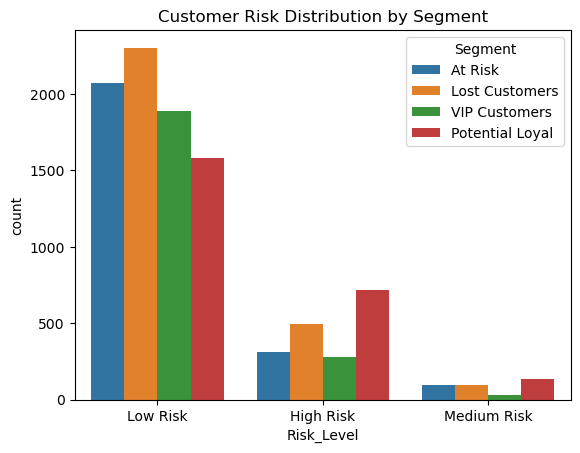

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Risk_Level", hue="Segment", data=df)
plt.title("Customer Risk Distribution by Segment")
plt.show()

In [25]:
df.to_csv("final_customer_intelligence.csv", index=False)
print ("saved successfully")

saved successfully
